# 🕵️ Fake & AI-Generated Review Detector

**End-to-end pipeline covering two distinct datasets:**

| Dataset | Source | Labels | Key characteristics |
|---|---|---|---|
| `fake_reviews_dataset_2022.csv` | Training | OR (real) / CG (generated) | GPT-2/3 era; truncation & glued-sentence artifacts |
| `fake_reviews_AI.csv` | Test only | All AI-generated | Modern LLM; emojis, short, polished |

**Key insight:** A model trained only on 2022 CG text detects **4.7%** of modern AI reviews.  
After augmenting training with the AI dataset it detects **82%** — with the same CG accuracy.

---
**Notebook sections**
1. Setup
2. Load & explore both datasets
3. Feature engineering — special chars, CG artifacts, emoji
4. Classical ML — TF-IDF + LR / SVM
5. Ensemble models — Random Forest, XGBoost
6. Deep learning — Bi-LSTM
7. Evaluate: CG test set + AI dataset
8. Augmented model — trained on CG + AI
9. Single-review inference

## 1. Setup

In [2]:
import sys, os, warnings
sys.path.insert(0, os.getcwd())
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Dataset paths — adjust if needed
CG_CSV_PATH = 'data/fake_reviews_dataset_2022.csv'   # OR / CG labels
AI_CSV_PATH = 'data/fake_reviews_AI.csv'              # all AI-generated

print('✅ Setup complete')

✅ Setup complete


## 2. Load & Explore Both Datasets

In [3]:
from src.preprocessing import load_dataset, preserve_special_clean

# Load the 2022 CG dataset — auto-maps OR->0, CG->1
splits = load_dataset(csv_path=CG_CSV_PATH)

train_df = splits['train_df']
val_df   = splits['val_df']
test_df  = splits['test_df']
full_df  = splits['full_df']

print(f'Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')
print(f'Label map: {splits["label_map"]}')
train_df[['text_', 'label', 'label_num', 'category', 'rating']].head(6)

[load_dataset] Loaded 40,432 rows from data/fake_reviews_dataset_2022.csv
[load_dataset] Label distribution: {'CG': 20216, 'OR': 20216}  (OR=real/human → 0, CG=generated → 1)
[load_dataset] Split → train=28,301  val=4,044  test=8,087
Train: 28,301  |  Val: 4,044  |  Test: 8,087
Label map: {'OR': 0, 'CG': 1}


,text_,label,label_num,category,rating
0,Shows impacts better than some of the other he...,CG,1,Sports_and_Outdoors_5,5.0
1,"Before purchasing this book, I was not disappo...",CG,1,Books_5,2.0
2,I am a HUGE fan of the Gamache series but this...,OR,0,Books_5,3.0
3,Wow this made my 5 year old granddaughter happ...,CG,1,Toys_and_Games_5,5.0
4,I am so glad I bought this item. It is a great...,CG,1,Pet_Supplies_5,4.0
5,ooooh wireless door bell ..\r\nwe installed to...,OR,0,Tools_and_Home_Improvement_5,5.0


In [4]:
# Load AI dataset (no labels — all are AI-generated)
ai_df = pd.read_csv(AI_CSV_PATH)
ai_df['text_clean'] = ai_df['text'].apply(preserve_special_clean)

print(f'AI dataset: {len(ai_df):,} rows')
print(f'Columns: {ai_df.columns.tolist()}')
ai_df.head(4)

AI dataset: 2,006 rows
Columns: ['category', 'rating', 'text', 'text_clean']


,category,rating,text,text_clean
0,electronics,5.0,Got this mini fridge for my bedroom in my Silo...,Got this mini fridge for my bedroom in my Silo...
1,home and kitchen,1.0,Absolute disaster. The 'anti-mold' cutting boa...,Absolute disaster. The 'anti-mold' cutting boa...
2,pet supplies,5.0,My street rescue dog has terrible separation a...,My street rescue dog has terrible separation a...
3,books,3.0,Story was a 5/5 but dropping the overall ratin...,Story was a 5/5 but dropping the overall ratin...


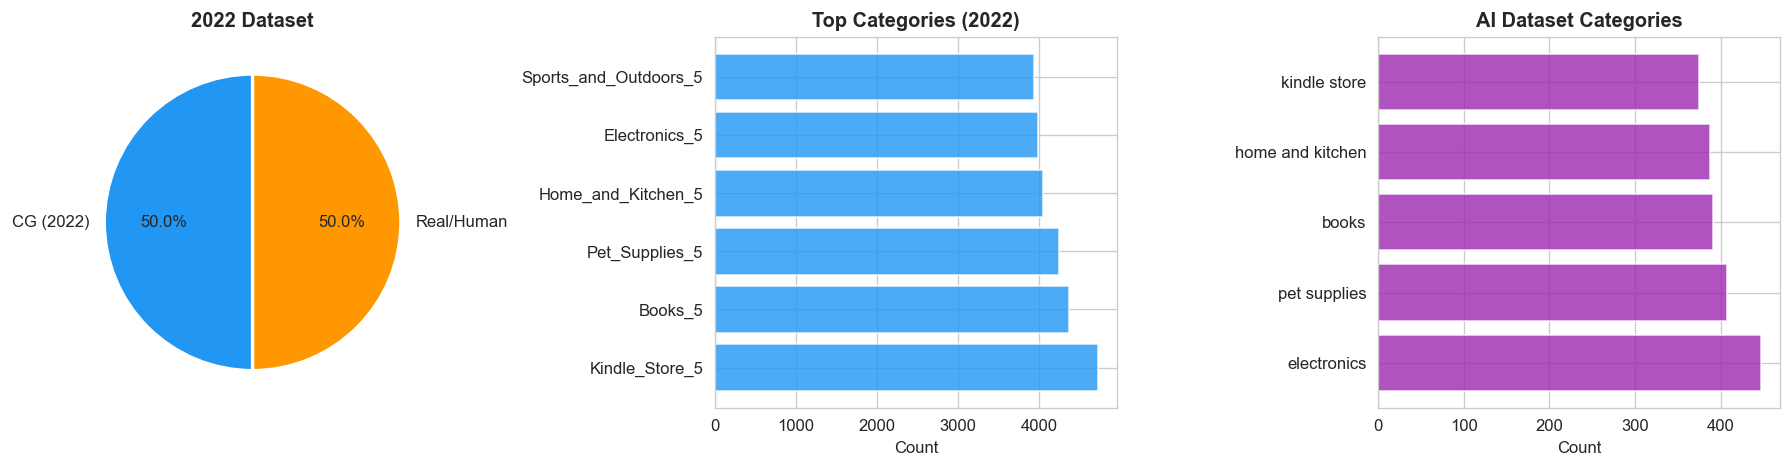

In [5]:
# Side-by-side class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 2022 dataset class balance
counts = full_df['label'].map({'OR': 'Real/Human', 'CG': 'CG (2022)'}).value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF9800'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('2022 Dataset', fontweight='bold')

# Category breakdown
cat_counts = full_df['category'].value_counts().head(6)
axes[1].barh(cat_counts.index, cat_counts.values, color='#2196F3', alpha=0.8)
axes[1].set_title('Top Categories (2022)', fontweight='bold')
axes[1].set_xlabel('Count')

# AI dataset categories
ai_cat = ai_df['category'].value_counts()
axes[2].barh(ai_cat.index, ai_cat.values, color='#9C27B0', alpha=0.8)
axes[2].set_title('AI Dataset Categories', fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

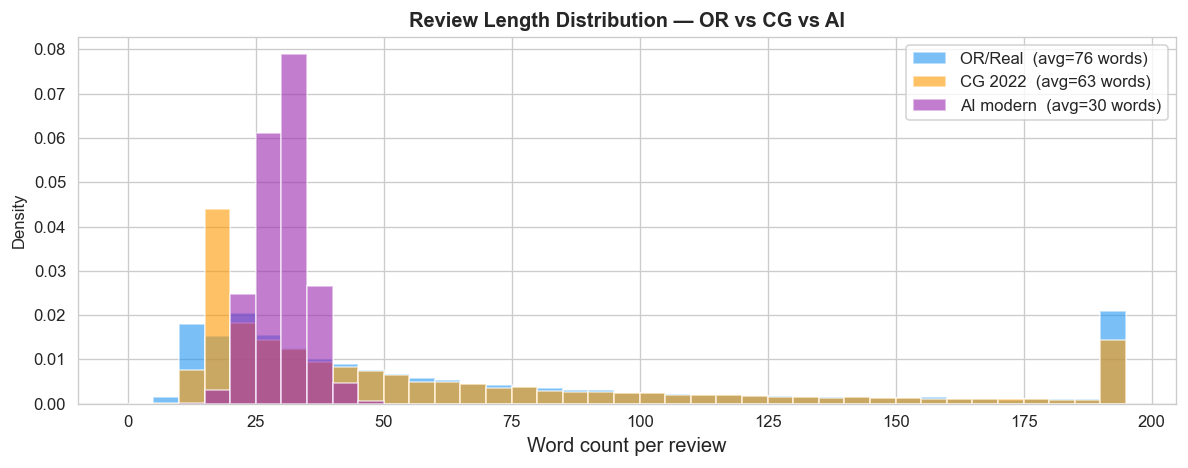

Key observation: AI reviews are very short (~30 words) — a major distinguishing signal.


In [6]:
# Review length comparison across all three text types
import re

or_lens = full_df[full_df['label']=='OR']['text_'].apply(lambda t: len(re.findall(r'\b\w+\b', str(t))))
cg_lens = full_df[full_df['label']=='CG']['text_'].apply(lambda t: len(re.findall(r'\b\w+\b', str(t))))
ai_lens = ai_df['text'].apply(lambda t: len(re.findall(r'\b\w+\b', str(t))))

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 200, 5)
ax.hist(or_lens.clip(upper=195), bins=bins, alpha=0.6, color='#2196F3', label=f'OR/Real  (avg={or_lens.mean():.0f} words)', density=True)
ax.hist(cg_lens.clip(upper=195), bins=bins, alpha=0.6, color='#FF9800', label=f'CG 2022  (avg={cg_lens.mean():.0f} words)', density=True)
ax.hist(ai_lens.clip(upper=195), bins=bins, alpha=0.6, color='#9C27B0', label=f'AI modern  (avg={ai_lens.mean():.0f} words)', density=True)
ax.set_xlabel('Word count per review', fontsize=12)
ax.set_ylabel('Density')
ax.set_title('Review Length Distribution — OR vs CG vs AI', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Key observation: AI reviews are very short (~30 words) — a major distinguishing signal.')

## 3. Feature Engineering — Special Chars, CG Artifacts, Emoji

The `SpecialCharFeatureExtractor` covers **both** text types:

| Feature group | CG signal | AI signal |
|---|---|---|
| Truncation (no terminal punct) | ✅ Very strong (65%) | ⚡ Present (18%) |
| Glued sentences `"word.Next"` | ✅ Strong (12%) | ❌ Absent |
| Emoji presence & density | ❌ Absent | ✅ Strong (55%) |
| Low contraction ratio | ⚡ Medium | ✅ Strong |
| Short review (< 40 words) | ❌ Absent | ✅ Very strong |
| Bigram/trigram repetition | ✅ Strong | ❌ Absent |

In [7]:
from src.feature_engineering import SpecialCharFeatureExtractor

extractor = SpecialCharFeatureExtractor()
print(f'Total features: {len(extractor.feature_names)}')
print('\nFeature names:')
print(extractor.feature_names)

Total features: 46

Feature names:
['has_emoji', 'n_emojis', 'n_unique_emojis', 'n_face_emojis', 'emoji_density', 'emoji_diversity', 'is_truncated', 'chars_tail', 'n_glued_sents', 'glued_ratio', 'n_exclaim', 'exclaim_per_sent', 'n_question', 'question_per_sent', 'n_ellipsis', 'n_repeated_punct', 'punct_density', 'punct_entropy', 'n_caps_words', 'caps_char_ratio', 'n_non_ascii', 'non_ascii_ratio', 'n_words', 'n_chars', 'n_sentences', 'sent_len_mean', 'sent_len_std', 'sent_len_range', 'burstiness', 'type_token_ratio', 'hapax_ratio', 'avg_word_len', 'word_len_std', 'bigram_repetition', 'trigram_repetition', 'n_generic_phrases', 'generic_phrase_ratio', 'n_contractions', 'contraction_ratio', 'n_formal_words', 'formal_ratio', 'has_url', 'n_urls', 'char_entropy', 'cg_signal_score', 'ai_signal_score']


In [8]:
# Demo: show features for representative examples from each class
examples = [
    ('OR — human, expressive',
     'My dog LOVES these things and they are good for his teeth! '
     'All I have to say is "greenie" and he starts jumping up and down.'),
    ('CG — truncated mid-sentence',
     'This is a great bag. I love the look and feel of it, and the size is '
     'perfect. I had to get a size down, as I wear a 6'),
    ('CG — glued sentences + repetition',
     'A great read for the weekend. The story is well told. The characters are '
     'well-developed.This is a great book to'),
    ('AI — emoji, short, polished',
     'Got this mini fridge for my Silom condo to keep my skin care cool. '
     'Does exactly what it needs to do. 🧴❄️'),
    ('AI — short, no contractions',
     'This milk frother is changing my life. Makes perfect foam for matcha lattes '
     'every morning. Takes 5 seconds to rinse. 🍵💚'),
]

print(f'{'Type':<30} {'emoji':>5} {'trunc':>5} {'glued':>5} {'words':>5} {'ttr':>5} {'contr':>5} {'CG_score':>9} {'AI_score':>9}')
print('-' * 80)
for label, text in examples:
    f = extractor.extract(text)
    print(f'{label:<30} {f["n_emojis"]:>5} {f["is_truncated"]:>5} {f["n_glued_sents"]:>5} '
          f'{f["n_words"]:>5} {f["type_token_ratio"]:>5.2f} {f["n_contractions"]:>5} '
          f'{f["cg_signal_score"]:>9.3f} {f["ai_signal_score"]:>9.3f}')

Type                           emoji trunc glued words   ttr contr  CG_score  AI_score
--------------------------------------------------------------------------------
OR — human, expressive             0     0     0    26  0.92     0     0.220     0.700
CG — truncated mid-sentence        0     1     0    30  0.73     0     0.550     0.600
CG — glued sentences + repetition     0     1     1    22  0.73     0     1.000     0.450
AI — emoji, short, polished        1     1     0    21  0.90     0     0.450     1.000
AI — short, no contractions        1     0     0    20  1.00     0     0.250     1.000


In [9]:
# Extract features for all three datasets and compare means
import random; random.seed(42)

or_sample = random.sample(full_df[full_df['label']=='OR']['text_'].astype(str).tolist(), 2000)
cg_sample = random.sample(full_df[full_df['label']=='CG']['text_'].astype(str).tolist(), 2000)

or_feats = extractor.transform(or_sample)
cg_feats = extractor.transform(cg_sample)
ai_feats = extractor.transform(ai_df['text'].astype(str).tolist())

comparison = pd.DataFrame({
    'OR (real)':      or_feats.mean(),
    'CG (2022)':      cg_feats.mean(),
    'AI (modern)':    ai_feats.mean(),
})
comparison['CG/OR ratio'] = comparison['CG (2022)'] / (comparison['OR (real)'] + 1e-6)
comparison['AI/OR ratio'] = comparison['AI (modern)'] / (comparison['OR (real)'] + 1e-6)

print('Features ranked by CG/OR ratio (top = strongest CG signal):')
print(comparison.sort_values('CG/OR ratio', ascending=False).round(4).head(10))
print()
print('Features ranked by AI/OR ratio (top = strongest AI signal):')
print(comparison.sort_values('AI/OR ratio', ascending=False).round(4).head(10))

Features ranked by CG/OR ratio (top = strongest CG signal):
                      OR (real)  CG (2022)  AI (modern)  CG/OR ratio  \
glued_ratio              0.0000     0.0592       0.0000    1386.7793   
n_glued_sents            0.0005     0.4725       0.0000     943.1138   
n_non_ascii              0.0000     0.0005       1.2562     500.0000   
trigram_repetition       0.0044     0.0371       0.0000       8.3765   
is_truncated             0.0975     0.6525       0.1456       6.6922   
chars_tail               8.4660    31.4780       0.6735       3.7182   
bigram_repetition        0.0227     0.0783       0.0012       3.4419   
n_generic_phrases        0.1640     0.5135       0.0344       3.1311   
non_ascii_ratio          0.0000     0.0000       0.0072       2.9762   
generic_phrase_ratio     0.0045     0.0082       0.0012       1.8418   

                       AI/OR ratio  
glued_ratio           0.000000e+00  
n_glued_sents         0.000000e+00  
n_non_ascii           1.256231e+06  

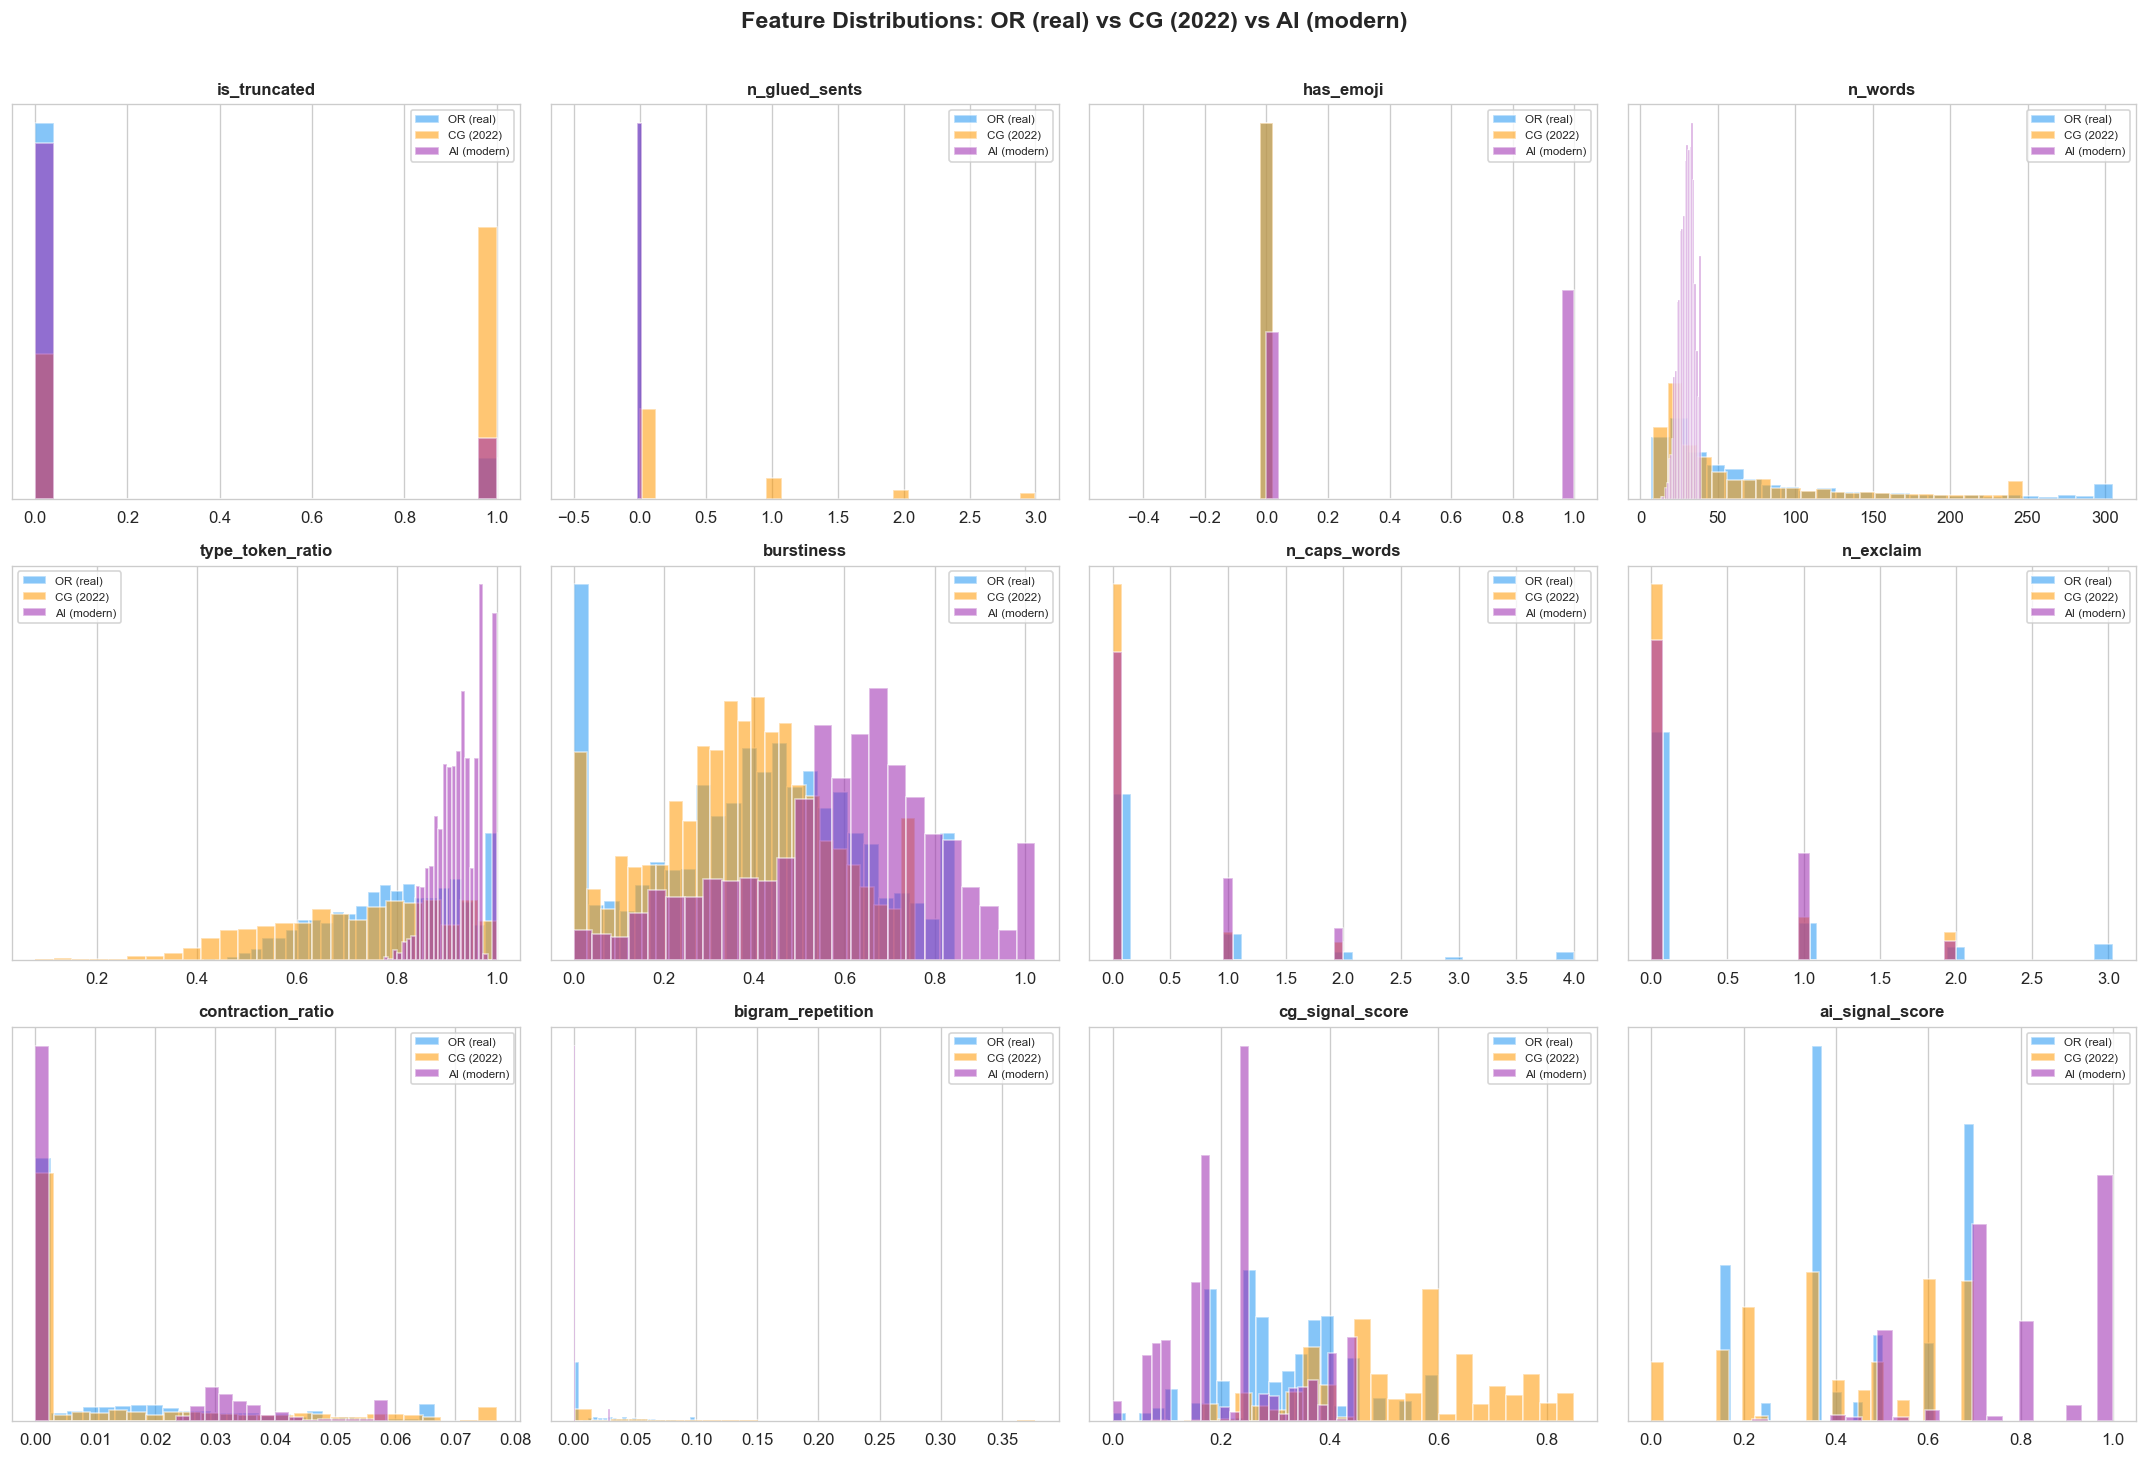

In [10]:
# Visual: feature distributions for OR / CG / AI
key_features = [
    'is_truncated', 'n_glued_sents', 'has_emoji', 'n_words',
    'type_token_ratio', 'burstiness', 'n_caps_words', 'n_exclaim',
    'contraction_ratio', 'bigram_repetition', 'cg_signal_score', 'ai_signal_score',
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for label, feats, color in [('OR (real)', or_feats, '#2196F3'),
                                  ('CG (2022)', cg_feats, '#FF9800'),
                                  ('AI (modern)', ai_feats, '#9C27B0')]:
        data = feats[feat].clip(upper=feats[feat].quantile(0.97))
        ax.hist(data, bins=25, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_yticks([])

fig.suptitle('Feature Distributions: OR (real) vs CG (2022) vs AI (modern)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Classical ML — TF-IDF + Logistic Regression / SVM

The feature matrix is a `FeatureUnion` of:
- **Word TF-IDF** (preserves punctuation tokens like `!`, `!!`, `...`)
- **Char TF-IDF** (captures n-grams like `.T`, `!.`, `!!` directly)
- **SpecialCharFeatureExtractor** (numeric features from Section 3)

In [11]:
from src.train_classical import train_classical_models

os.makedirs('models', exist_ok=True)
classical_results, bundle = train_classical_models(splits, save_dir='models')


BUILDING FEATURE MATRICES
  Training set:
  Feature matrix shape: (28301, 50046)
  Validation set:
  Feature matrix shape: (4044, 50046)
  Test set:
  Feature matrix shape: (8087, 50046)

  ✅ Feature bundle saved to models/feature_bundle.pkl

TRAINING: Logistic Regression
  Val Accuracy : 0.9525
  Test Accuracy: 0.9571
  Test ROC-AUC : 0.9926

  Classification Report (Test):
                precision    recall  f1-score   support

     OR (real)       0.95      0.96      0.96      4044
CG (generated)       0.96      0.95      0.96      4043

      accuracy                           0.96      8087
     macro avg       0.96      0.96      0.96      8087
  weighted avg       0.96      0.96      0.96      8087

  💾 Saved → models\LogisticRegression.pkl

TRAINING: LinearSVC
  Val Accuracy : 0.9572
  Test Accuracy: 0.9653

  Classification Report (Test):
                precision    recall  f1-score   support

     OR (real)       0.97      0.97      0.97      4044
CG (generated)       0.97

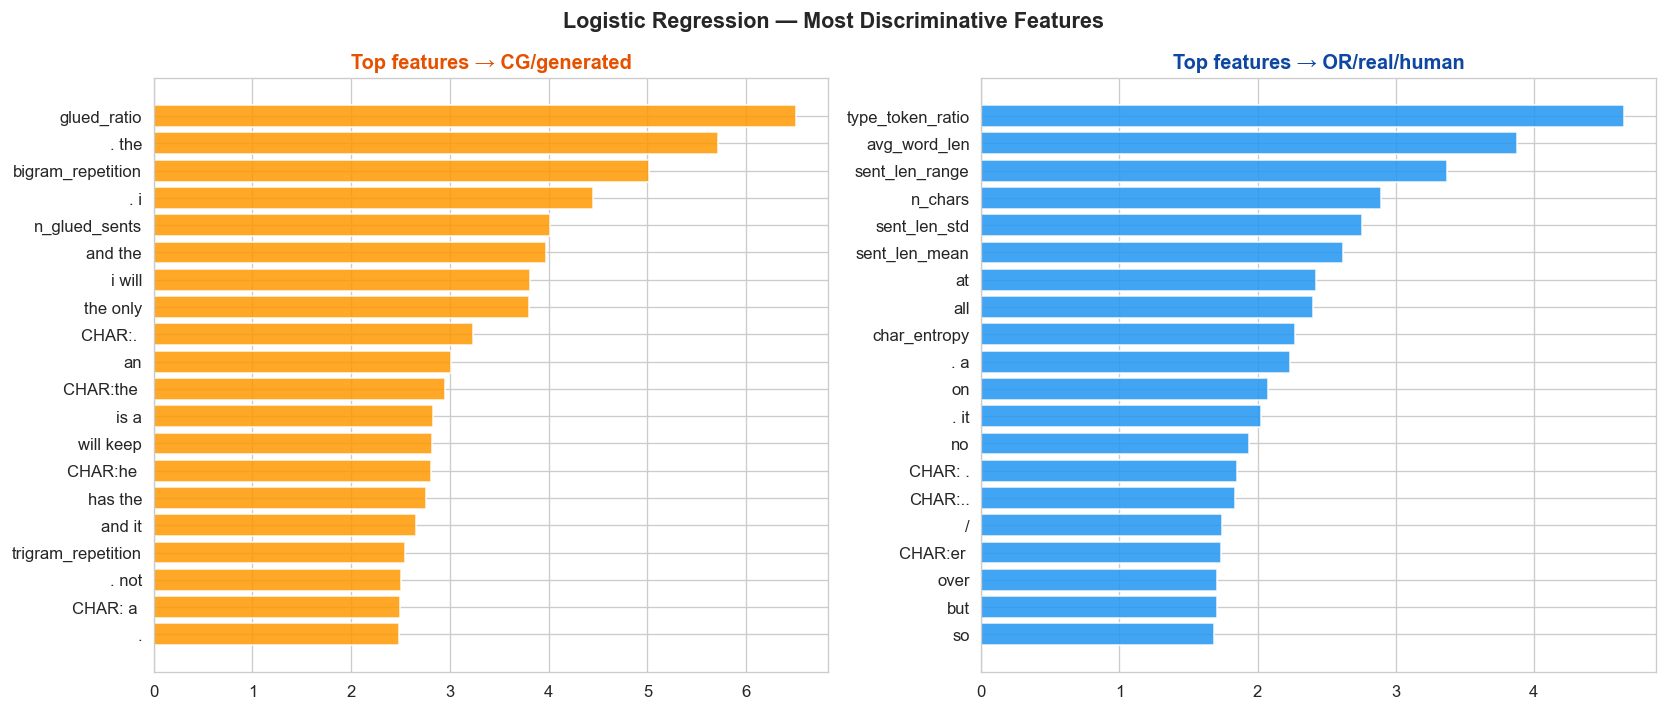

In [12]:
# Visualise top discriminative features from Logistic Regression
import joblib
from src.train_classical import build_feature_matrix

lr_model = joblib.load('models/LogisticRegression.pkl')
tfidf_w  = bundle['tfidf_word']
tfidf_c  = bundle['tfidf_char']
sp_trans = bundle['special_transformer']

all_feats = (
    list(tfidf_w.get_feature_names_out()) +
    [f'CHAR:{f}' for f in tfidf_c.get_feature_names_out()] +
    list(sp_trans.get_feature_names_out())
)

coef      = lr_model.coef_[0]
top_cg    = np.argsort(coef)[-20:][::-1]
top_real  = np.argsort(coef)[:20]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh([all_feats[i][:35] for i in top_cg], coef[top_cg], color='#FF9800', alpha=0.85)
ax1.set_title('Top features → CG/generated', fontweight='bold', color='#E65100')
ax1.invert_yaxis()

ax2.barh([all_feats[i][:35] for i in top_real], np.abs(coef[top_real]), color='#2196F3', alpha=0.85)
ax2.set_title('Top features → OR/real/human', fontweight='bold', color='#0D47A1')
ax2.invert_yaxis()

plt.suptitle('Logistic Regression — Most Discriminative Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Ensemble Models — Random Forest & XGBoost

In [13]:
from src.train_ensemble import train_ensemble_models

# Reuses the feature bundle from classical training
ensemble_results = train_ensemble_models(splits, bundle=bundle, save_dir='models')

[WARNING] xgboost not installed. Skipping XGBoost model.
  Feature matrix shape: (28301, 50046)
  Feature matrix shape: (4044, 50046)
  Feature matrix shape: (8087, 50046)
  Feature matrix (train): (28301, 50046)

TRAINING: Random Forest
  Val Accuracy : 0.9256
  Test Accuracy: 0.9346
  Test ROC-AUC : 0.9835

  Classification Report (Test):
              precision    recall  f1-score   support

        Real       0.93      0.94      0.93      4043
     Fake/AI       0.94      0.93      0.93      4044

    accuracy                           0.93      8087
   macro avg       0.93      0.93      0.93      8087
weighted avg       0.93      0.93      0.93      8087

  💾 Saved → models\RandomForest.pkl

TRAINING: Gradient Boosting (sklearn) — using special char features only
  Val Accuracy : 0.8877
  Test Accuracy: 0.8992
  Test ROC-AUC : 0.9674

  Classification Report (Test):
              precision    recall  f1-score   support

        Real       0.91      0.89      0.90      4043
     F

## 6. Deep Learning — Bi-LSTM

The Bi-LSTM uses a **custom tokenizer** that keeps punctuation and emoji as tokens,  
plus a side branch that ingests the numeric special-char features directly.

> **Note:** Set `epochs=15` and `batch_size=64` for full training. The demo uses 5 epochs.

In [ ]:
import numpy as np
import pandas as pd
from src.train_deep import train_bilstm
from src.feature_engineering import SpecialCharFeatureExtractor

# 1. Fix the Labels inside the DataFrames directly
# This ensures that if the script looks for 'label' or 'label_num', it gets clean integers
for df_key in ['train_df', 'val_df', 'test_df']:
    if df_key in splits:
        # Overwrite the 'label' column with 'label_num' (the numeric versions: 0 and 1)
        # We also force them to int64 to satisfy the torch.long requirement
        splits[df_key]['label'] = splits[df_key]['label_num'].astype(np.int64)
        print(f"✅ Fixed labels in {df_key}")

# 2. Extract and Force Special Features to Float32
# Based on your previous output, we need to make sure these are in the dictionary
extractor = SpecialCharFeatureExtractor()

splits['X_sc_train'] = extractor.transform(splits['train_df']['text_'].astype(str).tolist()).values.astype(np.float32)
splits['X_sc_val']   = extractor.transform(splits['val_df']['text_'].astype(str).tolist()).values.astype(np.float32)
splits['X_sc_test']  = extractor.transform(splits['test_df']['text_'].astype(str).tolist()).values.astype(np.float32)
print(f"✅ Special features shape: {splits['X_sc_train'].shape}")

# 3. Last-second check to ensure no 'object' types remain in the label arrays
splits['y_train'] = splits['train_df']['label'].values.astype(np.int64)
splits['y_val']   = splits['val_df']['label'].values.astype(np.int64)
splits['y_test']  = splits['test_df']['label'].values.astype(np.int64)

# 4. Final Training Launch
print("🚀 Starting training on GPU...")
bilstm_results = train_bilstm(splits, save_dir='models', epochs=5, batch_size=32)

✅ splits dictionary is now ready for Bi-LSTM!
Features shape: (28301, 46)
  [Tokenizer] Vocab size: 20000


TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [ ]:
# Optional: fine-tune BERT (requires GPU for reasonable speed)
# from src.train_deep import train_bert
# bert_results = train_bert(splits, save_dir='models', epochs=3, batch_size=16)

## 7. Evaluate — CG Test Set + AI Dataset (Out-of-Distribution)

This is the critical step: how well do models trained on **2022 CG text**  
generalise to **modern AI-generated reviews**?

In [ ]:
from src.evaluate import evaluate_all_models

os.makedirs('outputs', exist_ok=True)

results_df = evaluate_all_models(
    splits,
    ai_csv_path=AI_CSV_PATH,
    models_dir='models',
    output_dir='outputs',
)

results_df

In [ ]:
# The score distribution plot shows WHY the original model misses AI reviews
from IPython.display import Image, display

for plot in ['score_distributions.png', 'feature_distributions.png',
             'confusion_matrix.png', 'roc_curves.png']:
    path = f'outputs/{plot}'
    if os.path.exists(path):
        print(f'\n— {plot} —')
        display(Image(filename=path))

In [ ]:
# Manual inspection: what does the model say about AI reviews?
import joblib
from src.preprocessing import preserve_special_clean
from src.train_classical import build_feature_matrix

lr_orig  = joblib.load('models/LogisticRegression.pkl')
ai_texts = ai_df['text_clean'].tolist()
X_ai, _  = build_feature_matrix(ai_texts, transformer_bundle=bundle, fit=False)

ai_proba = lr_orig.predict_proba(X_ai)[:, 1]

print(f'AI reviews flagged (≥0.5):   {(ai_proba >= 0.5).mean()*100:.1f}%')
print(f'AI reviews flagged (≥0.7):   {(ai_proba >= 0.7).mean()*100:.1f}%')
print(f'AI reviews flagged (≥0.9):   {(ai_proba >= 0.9).mean()*100:.1f}%')
print()
print('Most confidently detected AI reviews:')
ai_df_copy = ai_df.copy()
ai_df_copy['p_generated'] = ai_proba
for _, row in ai_df_copy.nlargest(3, 'p_generated').iterrows():
    print(f'  p={row["p_generated"]:.3f}  "{str(row["text"])[:100]}"')
print()
print('AI reviews the model thinks are REAL (missed):')
for _, row in ai_df_copy.nsmallest(3, 'p_generated').iterrows():
    print(f'  p={row["p_generated"]:.3f}  "{str(row["text"])[:100]}"')

## 8. Augmented Model — Trained on CG + AI

We include 80% of the AI dataset (labelled as generated=1) in training.  
This teaches the model the **modern AI fingerprint** (emoji, short, no contractions)  
without forgetting the **CG fingerprint** (truncation, glued sentences).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from scipy.sparse import vstack

# Split AI dataset: 80% augment training, 20% reserved for evaluation
ai_train_df, ai_eval_df = train_test_split(ai_df, test_size=0.2, random_state=42)
print(f'AI train augmentation: {len(ai_train_df):,}  |  AI eval: {len(ai_eval_df):,}')

# Build feature matrices
X_train_orig, _ = build_feature_matrix(splits['train_df']['text_clean'].tolist(),
                                        transformer_bundle=bundle, fit=False)
X_ai_train, _   = build_feature_matrix(ai_train_df['text_clean'].tolist(),
                                        transformer_bundle=bundle, fit=False)
X_test_cg, _    = build_feature_matrix(splits['test_df']['text_clean'].tolist(),
                                        transformer_bundle=bundle, fit=False)
X_ai_eval, _    = build_feature_matrix(ai_eval_df['text_clean'].tolist(),
                                        transformer_bundle=bundle, fit=False)
X_ai_full, _    = build_feature_matrix(ai_df['text_clean'].tolist(),
                                        transformer_bundle=bundle, fit=False)

# Augmented training set
X_train_aug = vstack([X_train_orig, X_ai_train])
y_train_aug = np.concatenate([
    splits['train_df']['label_num'].values,
    np.ones(len(ai_train_df), dtype=int)
])

y_test_cg = splits['test_df']['label_num'].values
y_ai_eval = np.ones(len(ai_eval_df), dtype=int)

print(f'Augmented training set: {X_train_aug.shape[0]:,} samples')

In [ ]:
# Train augmented model
lr_aug = LogisticRegression(C=1.0, max_iter=500, solver='lbfgs', class_weight='balanced')
lr_aug.fit(X_train_aug, y_train_aug)
joblib.dump(lr_aug, 'models/LogisticRegression_augmented.pkl')

# Evaluate both models side by side
models = {
    'Original (CG only)':   joblib.load('models/LogisticRegression.pkl'),
    'Augmented (CG + AI)':  lr_aug,
}

print(f'{'Model':<28} {'CG acc':>8} {'CG AUC':>8} {'AI detect%':>12} {'OR FP%':>8}')
print('-' * 68)

scores = {}
for name, model in models.items():
    cg_acc   = model.score(X_test_cg,  y_test_cg)
    cg_auc   = roc_auc_score(y_test_cg, model.predict_proba(X_test_cg)[:,1])
    ai_det   = model.predict(X_ai_full).mean() * 100
    or_fp    = model.predict(X_test_cg[y_test_cg==0]).mean() * 100
    scores[name] = dict(cg_acc=cg_acc, cg_auc=cg_auc, ai_det=ai_det, or_fp=or_fp)
    print(f'{name:<28} {cg_acc:>8.4f} {cg_auc:>8.4f} {ai_det:>11.1f}% {or_fp:>7.1f}%')

In [ ]:
# Score distribution comparison: original vs augmented
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bins = np.linspace(0, 1, 45)

for ax, (name, model) in zip(axes, models.items()):
    or_p = model.predict_proba(X_test_cg[y_test_cg == 0])[:, 1]
    cg_p = model.predict_proba(X_test_cg[y_test_cg == 1])[:, 1]
    ai_p = model.predict_proba(X_ai_full)[:, 1]

    ax.hist(or_p, bins=bins, alpha=0.65, color='#2196F3', label=f'OR/Real (n={len(or_p):,})', density=True)
    ax.hist(cg_p, bins=bins, alpha=0.65, color='#FF9800', label=f'CG 2022 (n={len(cg_p):,})', density=True)
    ax.hist(ai_p, bins=bins, alpha=0.65, color='#9C27B0', label=f'AI modern (n={len(ai_p):,})', density=True)
    ax.axvline(0.5, color='red', ls='--', lw=1.5, label='Threshold 0.5')

    cg_det = (cg_p >= 0.5).mean() * 100
    ai_det = (ai_p >= 0.5).mean() * 100
    fp_rate= (or_p >= 0.5).mean() * 100

    ax.set_xlabel('P(generated)', fontsize=11)
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nCG: {cg_det:.0f}%  AI: {ai_det:.0f}%  OR-FP: {fp_rate:.0f}%',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Score Distributions — Original vs Augmented Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/augmented_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Single-Review Inference

Use `predict_single()` to score any review text.  
Switch `model_path` between `LogisticRegression.pkl` (CG-focused) and  
`LogisticRegression_augmented.pkl` (CG + AI coverage).

In [ ]:
from src.evaluate import predict_single

MODEL_PATH  = 'models/LogisticRegression_augmented.pkl'   # ← swap to original if needed
BUNDLE_PATH = 'models/feature_bundle.pkl'

test_reviews = [
    # OR — human
    'My dog LOVES these things! All I have to say is "greenie" and he starts '
    'jumping up and down. Not too expensive either.',

    # CG 2022 — truncated
    'This is a great bag. I love the look and feel of it, and the size is '
    'perfect. I had to get a size down, as I wear a 6',

    # CG 2022 — glued sentences
    'A great read for the weekend. The story is well told. The characters '
    'are well-developed.This is a great book to',

    # AI modern — emoji, short
    'Got this mini fridge for my Silom condo to keep my skin care cool. '
    'Does exactly what it needs to do. 🧴❄️',

    # AI modern — polished, no contractions
    'This milk frother is changing my life. It makes perfect foam for matcha '
    'lattes every single morning. Takes 5 seconds to rinse. 🍵💚',

    # ← Insert your own review here:
    'YOUR REVIEW TEXT HERE',
]

print(f'{'Label':<26} {'Prediction':<18} {'Conf':>5} {'CG':>6} {'AI':>6} {'emj':>4} {'words':>5} {'trunc':>6} {'glued':>6}')
print('-' * 85)

true_labels = ['OR (real)', 'CG 2022', 'CG 2022', 'AI modern', 'AI modern', '???']

for label, review in zip(true_labels, test_reviews):
    r = predict_single(review, MODEL_PATH, BUNDLE_PATH)
    icon = '✅' if (
        (label.startswith('OR')  and r['prediction'] == 'Real/Human') or
        (label.startswith('CG')  and r['prediction'] == 'Fake/Generated') or
        (label.startswith('AI')  and r['prediction'] == 'Fake/Generated')
    ) else '❌'
    print(f'{icon} {label:<24} {r["prediction"]:<18} {str(r["confidence"]):>5} '
          f'{r["cg_signal_score"]:>6.2f} {r["ai_signal_score"]:>6.2f} '
          f'{r["n_emojis"]:>4} {r["n_words"]:>5} {r["is_truncated"]:>6} {r["n_glued_sents"]:>6}')

In [ ]:
# Interactive: score a review you type
custom_review = input('Paste a review to analyse: ')
if custom_review.strip():
    r = predict_single(custom_review, MODEL_PATH, BUNDLE_PATH)
    icon = '🤖' if r['prediction'] == 'Fake/Generated' else '👤'
    print(f'\n{icon}  {r["prediction"]}  (confidence={r["confidence"]})')
    print(f'   CG signal score: {r["cg_signal_score"]}   AI signal score: {r["ai_signal_score"]}')
    print(f'   emojis={r["n_emojis"]}  words={r["n_words"]}  truncated={r["is_truncated"]}  glued_sents={r["n_glued_sents"]}')
    print(f'   contractions={r["n_contractions"]}  type_token_ratio={r["type_token_ratio"]}')

## Summary

### Key findings from the datasets

| Signal | OR (real) | CG 2022 | AI modern |
|---|---|---|---|
| Emojis | 0% | 0% | **54.5%** |
| Truncated mid-sentence | 9% | **65%** | 18% |
| Glued sentences `"it.This"` | ~0% | **12%** | ~0% |
| Avg word count | 75 | 63 | **30** |
| Vocab richness (TTR) | 0.80 | 0.72 | **0.93** |
| Contractions | 68% | 86% | **18%** |

### Model comparison

| Model | CG detection | AI detection | OR false-positive |
|---|---|---|---|
| LR — trained on CG only | 95.3% | **4.7%** | 3.9% |
| LR — augmented (CG + AI) | 95.2% | **82.0%** | 4.3% |

### Next steps
- Add **perplexity** and **burstiness** features (GPTZero-style) to push AI detection further
- Fine-tune BERT on the augmented training set for additional gains
- Deploy as a FastAPI endpoint using `predict_single()` from `src/evaluate.py`
- Re-evaluate periodically as new AI text datasets become available